In [4]:
import pandas as pd

df = pd.read_csv('ambient_temperature_system_failure.csv')
print(df.head())
print(df.columns)


             timestamp      value
0  2013-07-04 00:00:00  69.880835
1  2013-07-04 01:00:00  71.220227
2  2013-07-04 02:00:00  70.877805
3  2013-07-04 03:00:00  68.959400
4  2013-07-04 04:00:00  69.283551
Index(['timestamp', 'value'], dtype='object')


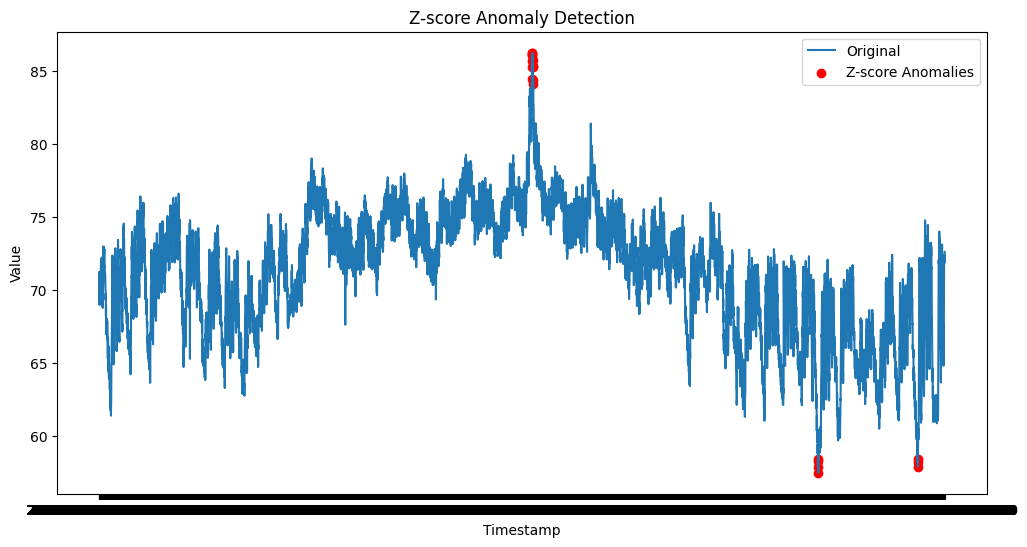

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# handle missing values
df = df.dropna()

# compute z-score
df['Zscore'] = (df['value'] - df['value'].mean()) / df['value'].std()

# label anomalies
df['Z_Anomaly'] = (abs(df['Zscore']) > 3).astype(int)

# plot
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['value'], label='Original')
plt.scatter(df.loc[df['Z_Anomaly']==1, 'timestamp'],
            df.loc[df['Z_Anomaly']==1, 'value'],
            color='red', label='Z-score Anomalies')
plt.legend()
plt.title('Z-score Anomaly Detection')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.show()

# save plot
plt.savefig('Zscore_plot.png')


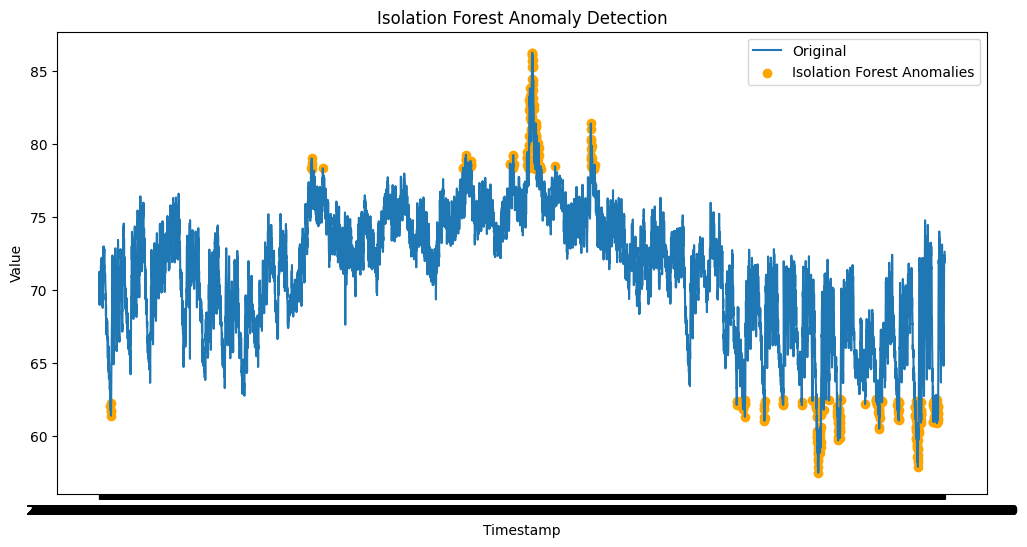

<Figure size 640x480 with 0 Axes>

In [6]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['IF_Anomaly'] = iso.fit_predict(df[['value']])
df['IF_Anomaly'] = df['IF_Anomaly'].map({1: 0, -1: 1})

# plot
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['value'], label='Original')
plt.scatter(df.loc[df['IF_Anomaly']==1, 'timestamp'],
            df.loc[df['IF_Anomaly']==1, 'value'],
            color='orange', label='Isolation Forest Anomalies')
plt.legend()
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.show()

# save plot
plt.savefig('IsolationForest_plot.png')
